# Week 2 — AITEX Preprocessing & Patch Generation
Checks the dataset, cleans and combines masks, applies CLAHE + denoising, and generates image/mask patches (defect and defect-free) for later weeks.

In [1]:
!pip install pillow pandas tqdm

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [4]:
DATASET_DIR = Path("/content/drive/MyDrive/ECE501/archive")

DEFECT_IMAGE_DIR = DATASET_DIR / "Defect_images"
MASK_DIR = DATASET_DIR / "Mask_images"
NODEFECT_IMAGE_DIR = DATASET_DIR / "NODefect_images"



In [5]:
print("=" * 60)
print("DATASET DIRECTORY CHECK")
print("=" * 60)

for directory in [DEFECT_IMAGE_DIR, MASK_DIR, NODEFECT_IMAGE_DIR]:
    if directory.exists():
        print(f"[OK] {directory}")
    else:
        print(f"[MISSING] {directory}")

DATASET DIRECTORY CHECK
[OK] /content/drive/MyDrive/ECE501/archive/Defect_images
[OK] /content/drive/MyDrive/ECE501/archive/Mask_images
[OK] /content/drive/MyDrive/ECE501/archive/NODefect_images


**Collect all image and mask files**  
Load file paths for defect images and their masks.

In [6]:
defect_images = sorted([
    p for p in DEFECT_IMAGE_DIR.iterdir()
    if p.suffix.lower() in [".png", ".jpg", ".jpeg"]
])

mask_files = sorted([
    p for p in MASK_DIR.iterdir()
    if p.suffix.lower() in [".png", ".jpg", ".jpeg"]
])

# NODefect_images in AITEX is organized as subfolders per fabric batch
# (e.g. NODefect_images/2306769/*.png), not a flat folder like Defect_images.
# rglob searches recursively so images inside subfolders are found too.
nodefect_images = sorted([
    p for p in NODEFECT_IMAGE_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in [".png", ".jpg", ".jpeg"]
])

print("=" * 60)
print("DATASET FILE COUNTS")
print("=" * 60)

print(f"Defect images    : {len(defect_images)}")
print(f"Mask files       : {len(mask_files)}")
print(f"No-defect images : {len(nodefect_images)}")

if len(nodefect_images) == 0:
    print("\n[WARNING] No defect-free images found.")
    print("Check NODEFECT_IMAGE_DIR path and folder structure:")
    for p in sorted(NODEFECT_IMAGE_DIR.iterdir())[:10]:
        print(f"  {p}")


DATASET FILE COUNTS
Defect images    : 106
Mask files       : 107
No-defect images : 141


**Create mask lookup**  
Map each image ID to its mask file(s).

In [7]:
mask_lookup = {}

for mask in mask_files:

    mask_name = mask.stem

    # Remove _mask1, _mask2, etc.
    if "_mask" in mask_name:
        image_id = mask_name.split("_mask")[0]
    else:
        image_id = mask_name

    if image_id not in mask_lookup:
        mask_lookup[image_id] = []

    mask_lookup[image_id].append(mask)

print("=" * 60)
print("MASK LOOKUP CREATED")
print("=" * 60)

print(f"Unique image IDs with masks: {len(mask_lookup)}")

MASK LOOKUP CREATED
Unique image IDs with masks: 105


**Check image–mask pairing**  
Find images with no mask or more than one mask.

In [8]:
images_without_masks = []
valid_image_mask_pairs = []
images_with_multiple_masks = {}

for image in defect_images:

    image_id = image.stem

    matched_masks = mask_lookup.get(image_id, [])

    if len(matched_masks) == 0:

        images_without_masks.append(image)

    elif len(matched_masks) == 1:

        valid_image_mask_pairs.append(
            (image, matched_masks[0])
        )

    else:

        images_with_multiple_masks[image] = sorted(matched_masks)


print("=" * 60)
print("IMAGE–MASK PAIRING CHECK")
print("=" * 60)

print(f"Valid image–mask pairs     : {len(valid_image_mask_pairs)}")
print(f"Images without masks      : {len(images_without_masks)}")
print(f"Images with multiple masks: {len(images_with_multiple_masks)}")

IMAGE–MASK PAIRING CHECK
Valid image–mask pairs     : 103
Images without masks      : 1
Images with multiple masks: 2


**PAIRING EXCEPTIONS**  
List the exact images with missing or multiple masks.

In [9]:
print("=" * 60)
print("IMAGES WITHOUT MASKS")
print("=" * 60)

if images_without_masks:

    for image in images_without_masks:
        print(image.name)

else:
    print("None")


print("\n" + "=" * 60)
print("IMAGES WITH MULTIPLE MASKS")
print("=" * 60)

if images_with_multiple_masks:

    for image, masks in images_with_multiple_masks.items():

        print(f"\nImage: {image.name}")

        for mask in masks:
            print(f"  {mask.name}")

else:
    print("None")

IMAGES WITHOUT MASKS
0100_025_08.png

IMAGES WITH MULTIPLE MASKS

Image: 0044_019_04.png
  0044_019_04_mask1.png
  0044_019_04_mask2.png

Image: 0097_030_03.png
  0097_030_03_mask1.png
  0097_030_03_mask2.png


**MASK PIXEL VALIDATION**  
Flag masks that contain no defect pixels.

In [10]:
def get_defect_pixels(mask_path):
    """
    Count non-zero pixels in a mask.
    Non-zero pixels represent the defect region.
    """
    mask = Image.open(mask_path).convert("L")
    mask_array = np.array(mask)

    return np.count_nonzero(mask_array)


empty_masks = []
valid_masks = []

for image, mask in valid_image_mask_pairs:

    defect_pixels = get_defect_pixels(mask)

    if defect_pixels == 0:
        empty_masks.append(mask)
    else:
        valid_masks.append(mask)


print("=" * 60)
print("MASK PIXEL VALIDATION")
print("=" * 60)

print(f"Valid masks : {len(valid_masks)}")
print(f"Empty masks : {len(empty_masks)}")

if empty_masks:
    print("\nEmpty masks:")

    for mask in empty_masks:
        print(f"  {mask.name}")

MASK PIXEL VALIDATION
Valid masks : 102
Empty masks : 1

Empty masks:
  0106_010_03_mask.png


**MULTIPLE-MASK VALIDATION**  
Check pixel overlap for images with multiple masks.

In [11]:
print("=" * 60)
print("MULTIPLE-MASK VALIDATION")
print("=" * 60)

for image, masks in images_with_multiple_masks.items():

    print(f"\nImage: {image.name}")

    mask_arrays = []

    for i, mask_path in enumerate(masks, start=1):

        mask = Image.open(mask_path).convert("L")
        mask_array = np.array(mask)

        defect_pixels = np.count_nonzero(mask_array)

        mask_arrays.append(mask_array > 0)

        print(f"Mask {i} defect pixels: {defect_pixels}")

    # Check overlap between masks
    if len(mask_arrays) >= 2:

        overlap = np.logical_and(
            mask_arrays[0],
            mask_arrays[1]
        )

        overlap_pixels = np.count_nonzero(overlap)

        print(f"Overlapping pixels  : {overlap_pixels}")

MULTIPLE-MASK VALIDATION

Image: 0044_019_04.png
Mask 1 defect pixels: 42
Mask 2 defect pixels: 40
Overlapping pixels  : 0

Image: 0097_030_03.png
Mask 1 defect pixels: 33
Mask 2 defect pixels: 53
Overlapping pixels  : 0


**IMAGE–MASK SIZE CHECK**  
Confirm each image and its mask have matching dimensions.

In [12]:
size_mismatches = []

for image, mask in valid_image_mask_pairs:

    image_size = Image.open(image).size
    mask_size = Image.open(mask).size

    if image_size != mask_size:
        size_mismatches.append(
            (image, mask, image_size, mask_size)
        )

print("=" * 60)
print("IMAGE–MASK SIZE CHECK")
print("=" * 60)

print(f"Size mismatches: {len(size_mismatches)}")

if size_mismatches:

    for image, mask, image_size, mask_size in size_mismatches:

        print(f"\nImage: {image.name}")
        print(f"Mask : {mask.name}")
        print(f"Image size: {image_size}")
        print(f"Mask size : {mask_size}")

else:
    print("All valid image–mask pairs have matching dimensions.")

IMAGE–MASK SIZE CHECK
Size mismatches: 0
All valid image–mask pairs have matching dimensions.


**FINAL DATASET INTEGRITY SUMMARY**  
Summarize all integrity checks on the raw dataset.

In [13]:
print("=" * 60)
print("FINAL DATASET INTEGRITY SUMMARY")
print("=" * 60)

print(f"\nTotal defect images        : {len(defect_images)}")
print(f"Total mask files           : {len(mask_files)}")
print(f"Valid image–mask pairs     : {len(valid_image_mask_pairs)}")
print(f"Images without masks       : {len(images_without_masks)}")
print(f"Images with multiple masks : {len(images_with_multiple_masks)}")
print(f"Empty masks                : {len(empty_masks)}")
print(f"Size mismatches            : {len(size_mismatches)}")


FINAL DATASET INTEGRITY SUMMARY

Total defect images        : 106
Total mask files           : 107
Valid image–mask pairs     : 103
Images without masks       : 1
Images with multiple masks : 2
Empty masks                : 1
Size mismatches            : 0


**IDENTIFIED DATASET ISSUES**  
List every issue found above in one place.

In [14]:
print("\n" + "=" * 60)
print("IDENTIFIED DATASET ISSUES")
print("=" * 60)

# Missing masks
if images_without_masks:
    print("\n[Missing mask]")
    for image in images_without_masks:
        print(f"  Image: {image.name}")

# Empty masks
if empty_masks:
    print("\n[Empty mask]")
    for mask in empty_masks:
        print(f"  Mask: {mask.name}")

# Multiple masks
if images_with_multiple_masks:
    print("\n[Multiple masks]")

    for image, masks in images_with_multiple_masks.items():

        print(f"  Image: {image.name}")

        for mask in masks:
            print(f"    - {mask.name}")

# Size mismatches
if size_mismatches:
    print("\n[Size mismatch]")

    for image, mask, image_size, mask_size in size_mismatches:

        print(f"  Image: {image.name}")
        print(f"  Mask : {mask.name}")
        print(f"  Image size: {image_size}")
        print(f"  Mask size : {mask_size}")


IDENTIFIED DATASET ISSUES

[Missing mask]
  Image: 0100_025_08.png

[Empty mask]
  Mask: 0106_010_03_mask.png

[Multiple masks]
  Image: 0044_019_04.png
    - 0044_019_04_mask1.png
    - 0044_019_04_mask2.png
  Image: 0097_030_03.png
    - 0097_030_03_mask1.png
    - 0097_030_03_mask2.png


**PREPROCESSING SETTINGS**  
Set target size and output folders for preprocessing.

In [15]:
TARGET_SIZE = (256, 256)

PROCESSED_DIR = Path(
    "/content/drive/MyDrive/ECE501/processed_data"
)

PROCESSED_IMAGE_DIR = PROCESSED_DIR / "images"
PROCESSED_MASK_DIR = PROCESSED_DIR / "masks"

PROCESSED_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_MASK_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("PREPROCESSING SETTINGS")
print("=" * 60)

print(f"Target image size : {TARGET_SIZE}")
print(f"Output directory  : {PROCESSED_DIR}")

PREPROCESSING SETTINGS
Target image size : (256, 256)
Output directory  : /content/drive/MyDrive/ECE501/processed_data


**CREATE FINAL IMAGE–MASK PAIRS**  
Combine single-mask and multi-mask images into one list.

In [16]:
final_pairs = []

# Add normal one-mask pairs
for image, mask in valid_image_mask_pairs:

    final_pairs.append({
        "image": image,
        "masks": [mask]
    })


# Add multiple-mask cases
for image, masks in images_with_multiple_masks.items():

    final_pairs.append({
        "image": image,
        "masks": masks
    })


print("=" * 60)
print("FINAL PREPROCESSING PAIRS")
print("=" * 60)

print(f"Total preprocessing pairs: {len(final_pairs)}")

FINAL PREPROCESSING PAIRS
Total preprocessing pairs: 105


**COMBINE MULTIPLE MASKS**  
Merge multiple masks for one image into a single binary mask.

In [17]:
def combine_masks(mask_paths):
    """
    Combine one or more mask files into a single binary mask.
    Any non-zero pixel in any input mask becomes 255.
    """

    combined_mask = None

    for mask_path in mask_paths:

        mask = Image.open(mask_path).convert("L")
        mask_array = np.array(mask)

        binary_mask = mask_array > 0

        if combined_mask is None:

            combined_mask = binary_mask

        else:

            combined_mask = np.logical_or(
                combined_mask,
                binary_mask
            )

    return (combined_mask.astype(np.uint8) * 255)

**PREPROCESS AND SAVE DATASET**  
Resize images/masks and save them for a quick visual check (not used for the final patches).

In [18]:
processed_count = 0

for pair in final_pairs:

    image_path = pair["image"]
    mask_paths = pair["masks"]

    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    image = Image.open(image_path).convert("RGB")

    # --------------------------------------------------------
    # Load and combine mask(s)
    # --------------------------------------------------------

    combined_mask = combine_masks(mask_paths)

    mask = Image.fromarray(combined_mask)

    # --------------------------------------------------------
    # Resize
    # --------------------------------------------------------

    image = image.resize(
        TARGET_SIZE,
        Image.Resampling.BILINEAR
    )

    mask = mask.resize(
        TARGET_SIZE,
        Image.Resampling.NEAREST
    )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    output_image = PROCESSED_IMAGE_DIR / image_path.name
    output_mask = PROCESSED_MASK_DIR / image_path.name

    image.save(output_image)
    mask.save(output_mask)

    processed_count += 1


print("=" * 60)
print("PREPROCESSING COMPLETE")
print("=" * 60)

print(f"Processed images : {processed_count}")
print(f"Target size      : {TARGET_SIZE}")
print(f"Images saved to  : {PROCESSED_IMAGE_DIR}")
print(f"Masks saved to   : {PROCESSED_MASK_DIR}")

PREPROCESSING COMPLETE
Processed images : 105
Target size      : (256, 256)
Images saved to  : /content/drive/MyDrive/ECE501/processed_data/images
Masks saved to   : /content/drive/MyDrive/ECE501/processed_data/masks


**VERIFY PROCESSED DATASET**  
Check that the resized images and masks saved correctly.

In [19]:
processed_images = sorted([
    p for p in PROCESSED_IMAGE_DIR.iterdir()
    if p.suffix.lower() == ".png"
])

processed_masks = sorted([
    p for p in PROCESSED_MASK_DIR.iterdir()
    if p.suffix.lower() == ".png"
])

print("=" * 60)
print("PROCESSED DATASET VERIFICATION")
print("=" * 60)

print(f"Processed images : {len(processed_images)}")
print(f"Processed masks  : {len(processed_masks)}")

size_errors = []
empty_processed_masks = []

for image_path in processed_images:

    mask_path = PROCESSED_MASK_DIR / image_path.name

    if not mask_path.exists():
        size_errors.append(
            (image_path.name, "Missing mask")
        )
        continue

    image = Image.open(image_path)
    mask = Image.open(mask_path)

    if image.size != TARGET_SIZE:
        size_errors.append(
            (image_path.name, "Incorrect image size")
        )

    if mask.size != TARGET_SIZE:
        size_errors.append(
            (image_path.name, "Incorrect mask size")
        )

    mask_array = np.array(mask)

    if np.count_nonzero(mask_array) == 0:
        empty_processed_masks.append(mask_path.name)


print(f"Size errors       : {len(size_errors)}")
print(f"Empty masks       : {len(empty_processed_masks)}")

PROCESSED DATASET VERIFICATION
Processed images : 105
Processed masks  : 105
Size errors       : 0
Empty masks       : 33


**MASK VALUE VALIDATION**  
Confirm all mask pixels are strictly 0 or 255.

In [20]:
invalid_masks = []

for mask_path in processed_masks:

    mask_array = np.array(
        Image.open(mask_path).convert("L")
    )

    unique_values = np.unique(mask_array)

    if not np.all(np.isin(unique_values, [0, 255])):

        invalid_masks.append(
            (mask_path.name, unique_values)
        )


print("=" * 60)
print("MASK VALUE VALIDATION")
print("=" * 60)

print(f"Total masks checked : {len(processed_masks)}")
print(f"Invalid masks       : {len(invalid_masks)}")

if invalid_masks:

    for name, values in invalid_masks:
        print(f"{name}: {values}")

else:

    print("All masks contain only binary values: 0 and 255.")

MASK VALUE VALIDATION
Total masks checked : 105
Invalid masks       : 0
All masks contain only binary values: 0 and 255.


**VISUALIZE PROCESSED IMAGE AND MASK**  
Show one resized image with its mask.

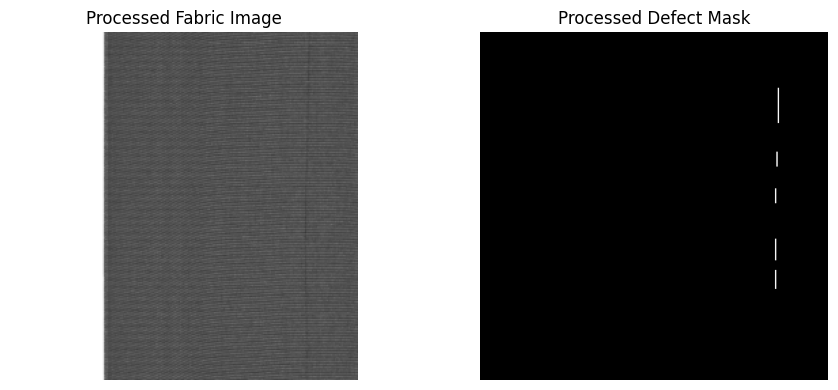

In [21]:
sample_image = processed_images[0]
sample_mask = PROCESSED_MASK_DIR / sample_image.name

image = Image.open(sample_image)
mask = Image.open(sample_mask)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Processed Fabric Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Processed Defect Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

**CREATE USABLE ORIGINAL IMAGE–MASK PAIRS FOR PATCHING**  
Build the list of images used for patches, excluding bad ones.

In [22]:
patch_pairs = []

# Build exclusion set dynamically from the checks already run in
# Cells 10 (images_without_masks) and 14 (empty_masks), instead of
# hardcoding filenames — so this still works if the dataset changes.
excluded_images = set(img.name for img in images_without_masks)

empty_mask_names = set(m.name for m in empty_masks)
for image, mask in valid_image_mask_pairs:
    if mask.name in empty_mask_names:
        excluded_images.add(image.name)

for image in defect_images:

    if image.name in excluded_images:
        continue

    image_id = image.stem
    masks = mask_lookup.get(image_id, [])

    if len(masks) > 0:

        patch_pairs.append({
            "image": image,
            "masks": masks
        })

print("=" * 60)
print("PATCH SOURCE PAIRS")
print("=" * 60)

print(f"Excluded (no mask / empty mask): {len(excluded_images)}")
print(f"Usable original images: {len(patch_pairs)}")


PATCH SOURCE PAIRS
Excluded (no mask / empty mask): 2
Usable original images: 104


**DEFECT-FREE IMAGE PAIRS FOR PATCHING**  
Build the list of defect-free images used for patches.

In [23]:
nodefect_pairs = []

for image_path in nodefect_images:
    nodefect_pairs.append({
        "image": image_path
    })

print("=" * 60)
print("DEFECT-FREE IMAGE PAIRS")
print("=" * 60)
print(f"Defect-free images available : {len(nodefect_pairs)}")


DEFECT-FREE IMAGE PAIRS
Defect-free images available : 141


**EXTRACT FABRIC TYPE FROM FILENAMES**  
Get fabric type from each filename for later fabric-wise analysis.

In [24]:
def get_fabric_type(image_path):
    """
    Extract fabric type from the numeric prefix
    of the AITEX filename.
    """
    return image_path.stem.split("_")[0]


fabric_types = {}

for image_path in defect_images:
    fabric_type = get_fabric_type(image_path)

    if fabric_type not in fabric_types:
        fabric_types[fabric_type] = []

    fabric_types[fabric_type].append(image_path)

for image_path in nodefect_images:
    fabric_type = get_fabric_type(image_path)

    if fabric_type not in fabric_types:
        fabric_types[fabric_type] = []

    fabric_types[fabric_type].append(image_path)


print("=" * 60)
print("FABRIC TYPE EXTRACTION")
print("=" * 60)

print(f"Fabric types found : {len(fabric_types)}")

for fabric_type, images in sorted(fabric_types.items()):
    print(f"Fabric type {fabric_type} : {len(images)} images")

FABRIC TYPE EXTRACTION
Fabric types found : 109
Fabric type 0001 : 8 images
Fabric type 0002 : 8 images
Fabric type 0003 : 8 images
Fabric type 0004 : 8 images
Fabric type 0005 : 8 images
Fabric type 0006 : 8 images
Fabric type 0007 : 7 images
Fabric type 0008 : 7 images
Fabric type 0009 : 7 images
Fabric type 0010 : 8 images
Fabric type 0011 : 8 images
Fabric type 0012 : 8 images
Fabric type 0013 : 8 images
Fabric type 0014 : 8 images
Fabric type 0015 : 8 images
Fabric type 0016 : 8 images
Fabric type 0017 : 8 images
Fabric type 0018 : 9 images
Fabric type 0019 : 8 images
Fabric type 0020 : 8 images
Fabric type 0021 : 1 images
Fabric type 0022 : 1 images
Fabric type 0023 : 1 images
Fabric type 0024 : 1 images
Fabric type 0025 : 1 images
Fabric type 0026 : 1 images
Fabric type 0027 : 1 images
Fabric type 0028 : 1 images
Fabric type 0029 : 1 images
Fabric type 0030 : 1 images
Fabric type 0031 : 1 images
Fabric type 0032 : 1 images
Fabric type 0033 : 1 images
Fabric type 0034 : 1 images


**PATCH GENERATION SETTINGS**  
Set patch size, stride, and output folders.

In [25]:
PATCH_SIZE = 256
STRIDE = 128

PATCHED_DIR = Path(
    "/content/drive/MyDrive/ECE501/processed_patches"
)

PATCH_IMAGE_DIR = PATCHED_DIR / "images"
PATCH_MASK_DIR = PATCHED_DIR / "masks"

PATCH_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
PATCH_MASK_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("PATCH GENERATION SETTINGS")
print("=" * 60)

print(f"Patch size : {PATCH_SIZE} × {PATCH_SIZE}")
print(f"Stride     : {STRIDE}")
print(f"Overlap    : {PATCH_SIZE - STRIDE} pixels")

PATCH GENERATION SETTINGS
Patch size : 256 × 256
Stride     : 128
Overlap    : 128 pixels


**PATCH GENERATION FUNCTION**  
Function that splits an image and mask into fixed-size patches.

In [26]:
def extract_patches(image, mask, patch_size=256, stride=128):

    height, width = image.shape[:2]

    image_patches = []
    mask_patches = []

    # Make sure mask is 2D
    if len(mask.shape) == 3:
        mask = mask[:, :, 0]

    # Pad image and mask if needed
    padded_height = max(height, patch_size)
    padded_width = max(width, patch_size)

    if padded_height != height or padded_width != width:

        pad_bottom = padded_height - height
        pad_right = padded_width - width

        image = cv2.copyMakeBorder(
            image,
            0,
            pad_bottom,
            0,
            pad_right,
            cv2.BORDER_REFLECT
        )

        mask = cv2.copyMakeBorder(
            mask,
            0,
            pad_bottom,
            0,
            pad_right,
            cv2.BORDER_CONSTANT,
            value=0
        )

        height, width = image.shape[:2]

    # Generate coordinates
    y_positions = list(
        range(0, height - patch_size + 1, stride)
    )

    x_positions = list(
        range(0, width - patch_size + 1, stride)
    )

    # Ensure last row/column is covered
    if y_positions[-1] != height - patch_size:
        y_positions.append(height - patch_size)

    if x_positions[-1] != width - patch_size:
        x_positions.append(width - patch_size)

    for y in y_positions:

        for x in x_positions:

            image_patch = image[
                y:y + patch_size,
                x:x + patch_size
            ]

            mask_patch = mask[
                y:y + patch_size,
                x:x + patch_size
            ]

            # Force binary mask
            mask_patch = np.where(
                mask_patch > 0,
                255,
                0
            ).astype(np.uint8)

            image_patches.append(
                (x, y, image_patch)
            )

            mask_patches.append(
                (x, y, mask_patch)
            )

    return image_patches, mask_patches

**GENERATE IMAGE–MASK PATCHES**  
Apply CLAHE and denoising, then generate defect image/mask patches.

In [27]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

def preprocess_image(image):
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

    l_channel, a_channel, b_channel = cv2.split(lab)

    l_enhanced = clahe.apply(l_channel)

    lab_enhanced = cv2.merge(
        [l_enhanced, a_channel, b_channel]
    )

    enhanced = cv2.cvtColor(
        lab_enhanced,
        cv2.COLOR_LAB2BGR
    )

    denoised = cv2.GaussianBlur(
        enhanced,
        (3, 3),
        0
    )

    return denoised

In [28]:
for file in PATCH_IMAGE_DIR.glob("*.png"):
    file.unlink()

for file in PATCH_MASK_DIR.glob("*.png"):
    file.unlink()

total_patches = 0
defect_patches = 0

for pair in patch_pairs:

    image_path = pair["image"]
    mask_paths = pair["masks"]

    image = cv2.imread(str(image_path))

    if image is None:
        print(f"Could not load: {image_path.name}")
        continue

    # Apply CLAHE and Gaussian denoising
    image = preprocess_image(image)

    # Combine masks
    combined_mask = combine_masks(mask_paths)

    # Extract image and corresponding mask patches
    image_patches, mask_patches = extract_patches(
        image,
        combined_mask,
        PATCH_SIZE,
        STRIDE
    )

    for (
        (x, y, image_patch),
        (_, _, mask_patch)
    ) in zip(image_patches, mask_patches):

        base_name = image_path.stem
        filename = f"{base_name}_x{x}_y{y}.png"

        cv2.imwrite(
            str(PATCH_IMAGE_DIR / filename),
            image_patch
        )

        cv2.imwrite(
            str(PATCH_MASK_DIR / filename),
            mask_patch
        )

        total_patches += 1

        if np.count_nonzero(mask_patch) > 0:
            defect_patches += 1

print("=" * 60)
print("PREPROCESSED PATCH GENERATION COMPLETE")
print("=" * 60)

print(f"Total patches generated   : {total_patches}")
print(f"Defect-containing patches : {defect_patches}")
print(f"Background-only patches   : {total_patches - defect_patches}")

PREPROCESSED PATCH GENERATION COMPLETE
Total patches generated   : 3222
Defect-containing patches : 367
Background-only patches   : 2855


**GENERATE DEFECT-FREE IMAGE PATCHES**  
Apply the same preprocessing and generate patches from defect-free images.

In [29]:
NODEFECT_PATCH_DIR = PATCH_IMAGE_DIR.parent / "nodefect_images"
NODEFECT_PATCH_DIR.mkdir(parents=True, exist_ok=True)

for file in NODEFECT_PATCH_DIR.glob("*.png"):
    file.unlink()

total_nodefect_patches = 0

for pair in nodefect_pairs:

    image_path = pair["image"]

    image = cv2.imread(str(image_path))

    if image is None:
        print(f"Could not load: {image_path.name}")
        continue

    # Apply the same preprocessing
    image = preprocess_image(image)

    image_patches, _ = extract_patches(
        image,
        np.zeros(image.shape[:2], dtype=np.uint8),
        PATCH_SIZE,
        STRIDE
    )

    for x, y, image_patch in image_patches:

        filename = f"{image_path.stem}_x{x}_y{y}.png"

        cv2.imwrite(
            str(NODEFECT_PATCH_DIR / filename),
            image_patch
        )

        total_nodefect_patches += 1

print("=" * 60)
print("DEFECT-FREE PATCH GENERATION COMPLETE")
print("=" * 60)
print(f"Defect-free patches generated : {total_nodefect_patches}")

DEFECT-FREE PATCH GENERATION COMPLETE
Defect-free patches generated : 4371


**PATCH MASK CONTENT CHECK**  
Count how many patches contain defect pixels.

In [30]:
patch_masks = sorted(
    PATCH_MASK_DIR.glob("*.png")
)

non_empty = 0
empty = 0

for mask_path in patch_masks:

    mask = np.array(
        Image.open(mask_path).convert("L")
    )

    if np.count_nonzero(mask) > 0:
        non_empty += 1
    else:
        empty += 1


print("=" * 60)
print("PATCH MASK CONTENT CHECK")
print("=" * 60)

print(f"Total mask patches : {len(patch_masks)}")
print(f"Non-empty masks    : {non_empty}")
print(f"Empty masks        : {empty}")

PATCH MASK CONTENT CHECK
Total mask patches : 3222
Non-empty masks    : 367
Empty masks        : 2855


**PATCH DATASET VALIDATION**  
Confirm every patch has a matching mask of the correct size.

In [31]:
patch_images = sorted(
    PATCH_IMAGE_DIR.glob("*.png")
)

patch_masks = sorted(
    PATCH_MASK_DIR.glob("*.png")
)

mask_names = {p.name for p in patch_masks}

missing_patch_masks = []
patch_size_mismatches = []

for image_path in patch_images:

    # Check corresponding mask exists
    if image_path.name not in mask_names:
        missing_patch_masks.append(image_path.name)
        continue

    mask_path = PATCH_MASK_DIR / image_path.name

    image = Image.open(image_path)
    mask = Image.open(mask_path)

    # Check image size
    if image.size != (PATCH_SIZE, PATCH_SIZE):
        patch_size_mismatches.append(
            (image_path.name, "Image", image.size)
        )

    # Check mask size
    if mask.size != (PATCH_SIZE, PATCH_SIZE):
        patch_size_mismatches.append(
            (mask_path.name, "Mask", mask.size)
        )


print("=" * 60)
print("PATCH DATASET VALIDATION")
print("=" * 60)

print(f"Image patches       : {len(patch_images)}")
print(f"Mask patches        : {len(patch_masks)}")
print(f"Missing masks       : {len(missing_patch_masks)}")
print(f"Size mismatches     : {len(patch_size_mismatches)}")

if len(missing_patch_masks) == 0:
    print("\n[OK] Every image patch has a corresponding mask.")

if len(patch_size_mismatches) == 0:
    print("[OK] All image and mask patches are 256 × 256.")

PATCH DATASET VALIDATION
Image patches       : 3222
Mask patches        : 3222
Missing masks       : 0
Size mismatches     : 0

[OK] Every image patch has a corresponding mask.
[OK] All image and mask patches are 256 × 256.


**MASK VALUE VALIDATION**  
Confirm all patch mask pixels are strictly 0 or 255.

In [32]:
invalid_patch_masks = []

for mask_path in patch_masks:

    mask = np.array(
        Image.open(mask_path).convert("L")
    )

    unique_values = np.unique(mask)

    if not np.all(
        np.isin(unique_values, [0, 255])
    ):
        invalid_patch_masks.append(
            (mask_path.name, unique_values)
        )


print("=" * 60)
print("PATCH MASK VALUE VALIDATION")
print("=" * 60)

print(f"Total masks checked : {len(patch_masks)}")
print(f"Invalid masks       : {len(invalid_patch_masks)}")

if len(invalid_patch_masks) == 0:
    print("[OK] All masks contain only 0 and 255.")
else:
    print("[CHECK REQUIRED] Some masks contain unexpected values.")

PATCH MASK VALUE VALIDATION
Total masks checked : 3222
Invalid masks       : 0
[OK] All masks contain only 0 and 255.


**VISUAL QUALITY CHECK**  
Show one defect patch with its mask.

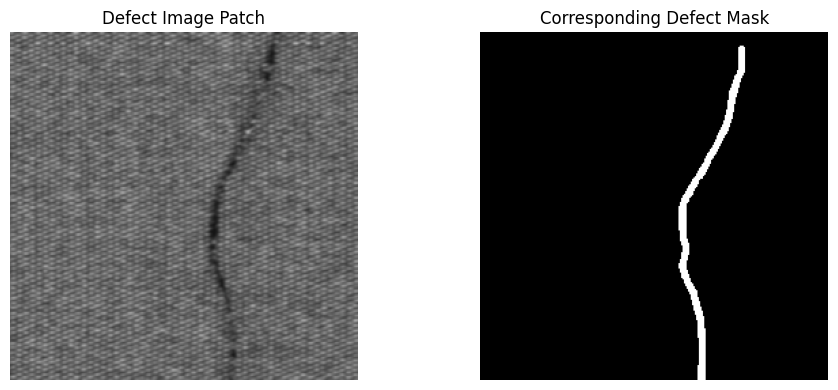

In [33]:
sample_image_path = None

for image_path in patch_images:

    mask_path = PATCH_MASK_DIR / image_path.name

    mask = np.array(
        Image.open(mask_path).convert("L")
    )

    if np.count_nonzero(mask) > 0:
        sample_image_path = image_path
        break


sample_mask_path = PATCH_MASK_DIR / sample_image_path.name

image = cv2.cvtColor(
    cv2.imread(str(sample_image_path)),
    cv2.COLOR_BGR2RGB
)

mask = np.array(
    Image.open(sample_mask_path).convert("L")
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Defect Image Patch")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Corresponding Defect Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

**FINAL PREPROCESSING SUMMARY**  
Print an overall summary and pass/fail status for Week 2.

In [34]:
print("=" * 60)
print("WEEK 2 — FINAL PREPROCESSING SUMMARY")
print("=" * 60)

print("\nDataset:")
print(f"  Original defect images       : {len(defect_images)}")
print(f"  Original mask files          : {len(mask_files)}")
print(f"  Usable images                : {len(patch_pairs)}")

print("\nDataset integrity:")
print(f"  Images without masks         : {len(images_without_masks)}")
print(f"  Empty masks                  : {len(empty_masks)}")
print(f"  Images with multiple masks   : {len(images_with_multiple_masks)}")
print(f"  Image–mask size mismatches   : {len(size_mismatches)}")

print("\nPreprocessing:")
print("  CLAHE applied to luminance channel")
print("  Gaussian denoising applied")
print("  Masks converted to binary format (0/255)")
print("  Original dataset was not modified")

print("\nMask handling:")
print("  Multiple masks combined using logical OR")
print("  Missing-mask image excluded from processing")
print("  Empty-mask image excluded from processing")

print("\nPatch generation:")
print(f"  Patch size                   : {PATCH_SIZE} × {PATCH_SIZE}")
print(f"  Stride                       : {STRIDE}")
print(f"  Overlap                      : {PATCH_SIZE - STRIDE} pixels")
print(f"  Total patches generated     : {total_patches}")
print(f"  Defect-containing patches   : {defect_patches}")
print(f"  Background-only patches     : {total_patches - defect_patches}")
print(f"  Defect-free patches generated : {total_nodefect_patches}")

print("\nPatch validation:")
print(f"  Image patches                : {len(patch_images)}")
print(f"  Mask patches                 : {len(patch_masks)}")
print(f"  Missing patch masks          : {len(missing_patch_masks)}")
print(f"  Invalid mask patches         : {len(invalid_patch_masks)}")

print("\n" + "=" * 60)
print("WEEK 2 STATUS")
print("=" * 60)

if (
    len(patch_images) == len(patch_masks)
    and len(missing_patch_masks) == 0
    and len(invalid_patch_masks) == 0
    and len(size_mismatches) == 0
    and len(patch_size_mismatches) == 0
    and defect_patches > 0
    and total_nodefect_patches > 0
):
    print("[COMPLETED] Week 2 preprocessing pipeline completed.")
    print("[COMPLETED] Processed image–mask patch dataset passed validation.")
else:
    print("[CHECK REQUIRED] Review validation results.")

WEEK 2 — FINAL PREPROCESSING SUMMARY

Dataset:
  Original defect images       : 106
  Original mask files          : 107
  Usable images                : 104

Dataset integrity:
  Images without masks         : 1
  Empty masks                  : 1
  Images with multiple masks   : 2
  Image–mask size mismatches   : 0

Preprocessing:
  CLAHE applied to luminance channel
  Gaussian denoising applied
  Masks converted to binary format (0/255)
  Original dataset was not modified

Mask handling:
  Multiple masks combined using logical OR
  Missing-mask image excluded from processing
  Empty-mask image excluded from processing

Patch generation:
  Patch size                   : 256 × 256
  Stride                       : 128
  Overlap                      : 128 pixels
  Total patches generated     : 3222
  Defect-containing patches   : 367
  Background-only patches     : 2855
  Defect-free patches generated : 4371

Patch validation:
  Image patches                : 3222
  Mask patches         